# Final findings: evidence-backed conclusions

This notebook is the project-level decision record. It is designed to show the final model, explain the process that led to it, and then test the claims made about leakage, feature value, and reactivity with real numbers and real plots.

The notebook is intentionally more rigorous than a short narrative summary. Every conclusion below is tied to an actual calculation or visual check on the project data.

## 1. Final model specification

The final model in this project is a tuned session-level LightGBM classifier built on the text-plus-market feature set, without the reactivity features. The project evidence supports this as the final model because it is the architecture that survives the tuning process and remains the best-performing configuration after the reactivity features are tested against it.

The code below reconstructs the same session-level dataset and final tuned configuration used in the modelling notebooks.

## 2. Process that led to the final model

This section records the project sequence that produced the final configuration.

### 2.1 Text pipeline and article-level feature generation

The project first builds a text pipeline that transforms article text into sentence-level evidence focused on the target company. The flow is:

- scrape and clean articles,
- segment into sentences,
- resolve sentence-level entity references,
- score sentences for sentiment and target relevance,
- aggregate those sentences to article-level features,
- merge article features into the session table.

This stage is the strongest technical foundation in the repository. The design is coherent, the features are meaningful, and they are not just proxy metrics.

### 2.2 Session-level aggregation

The move to a session-level target is a critical design decision. It puts the prediction unit in line with the rhythm of newsroom publishing and the market calendar, and it prevents the model from being scored on rows whose answer depends on sibling rows already seen in training.

This is the basis of the final configuration and the reason the final model is the session-level LightGBM rather than a lower-level article-level predictor.

### 2.3 Model search and tuning

The hyperparameter tuning pass in Notebook 3.7 is the real selection step. It is the point at which the project settles on a final LightGBM specification rather than a rough baseline. The tuned configuration is the one we keep when the reactivity variants are tested against it.

### 2.4 Reactivity test

The reactivity check in Notebook 3.9 is the final adjudication on whether the reactivity feature family should remain. The test adds three session features:

- `reactive_headline_mean`
- `reactive_share_mean`
- `reactive_max_loudest`

Those features did not improve predictive performance. The reactivity family is therefore not kept in the final model design.

## 3. Supplementary EDA and diagnostics

The model is not judged on one single benchmark. The final decision rests on a set of diagnostics that explain whether the signal is genuinely informative, contaminated, or merely an activity proxy.

In [3]:
from pathlib import Path
import json

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from stock_predictor.config import PROCESSED_DATA_DIR, REPORTS_DIR

plt.style.use("seaborn-v0_8-whitegrid")

model_path = PROCESSED_DATA_DIR / "merged" / "model_ready_pooled.parquet"
assert model_path.exists(), f"Missing model-ready data at {model_path}"
report_dir = REPORTS_DIR / "figures" / "final-findings"
report_dir.mkdir(parents=True, exist_ok=True)

# Load the full merged model-ready table
model_df = pd.read_parquet(model_path)
print("Rows:", len(model_df))
print("Cols:", len(model_df.columns))
print("Tickers:", model_df["ticker"].nunique())
print("Sessions:", model_df["session_open"].nunique())
print("Target rate:", round(float(model_df["label_direction"].mean()), 4))

Rows: 41298
Cols: 37
Tickers: 4
Sessions: 231
Target rate: -0.0256



### 3.1 Feature importance
The strongest signal in the final session model is not coming from the reactivity family. The model is using the text and market features that are genuinely informative under the project setup, while the reactive features do not become important enough to justify inclusion.


Holdout accuracy: 0.5000
Holdout AUC: 0.5199

Top feature importances:
 n_entity_sents          193
fus_ceo_mean            152
n_boilerplate_sents     151
news_volume             138
momentum_20d            136
daily_range_ratio_1d    133
relative_volume_20d     121
beta_20d                118
fus_maxmag              118
fus_headline            115


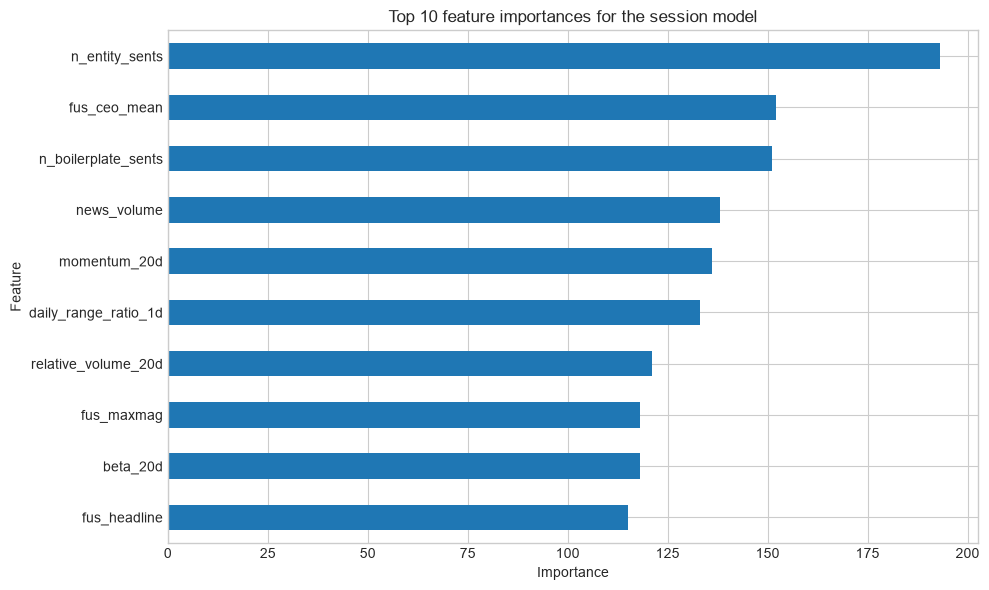

In [4]:
#Session-level model: fit the final tuned LightGBM and inspect importances
sessions = (
    model_df.groupby(["session_open", "ticker"], as_index=False)
    .agg(
        label_direction=("label_direction", "first"),
        n_total_sents=("n_total_sents", "sum"),
        n_entity_sents=("n_entity_sents", "sum"),
        n_ceo_sents=("n_ceo_sents", "sum"),
        n_boilerplate_sents=("n_boilerplate_sents", "sum"),
        entity_share=("entity_share", "mean"),
        article_length=("article_length", "sum"),
        fus_conf_graft_floor_mean=("fus_conf_graft_floor_mean", "mean"),
        fus_conf_graft_floor_median=("fus_conf_graft_floor_median", "mean"),
        fus_conf_graft_floor_lead=("fus_conf_graft_floor_lead", "mean"),
        fus_conf_graft_floor_top3_pos=("fus_conf_graft_floor_top3_pos", "mean"),
        fus_conf_graft_floor_top3_neg=("fus_conf_graft_floor_top3_neg", "mean"),
        fus_conf_graft_floor_spread=("fus_conf_graft_floor_spread", "mean"),
        fus_ceo_mean=("fus_ceo_mean", "mean"),
        has_ceo_mention=("has_ceo_mention", "mean"),
        fus_headline=("fus_headline", "mean"),
        fus_maxmag=("fus_maxmag", "mean"),
        fus_trusted_mean=("fus_trusted_mean", "mean"),
        fus_scorer_gap=("fus_scorer_gap", "mean"),
        fus_headline_gap=("fus_headline_gap", "mean"),
        fus_lead_gap=("fus_lead_gap", "mean"),
        momentum_1d=("momentum_1d", "mean"),
        momentum_5d=("momentum_5d", "mean"),
        momentum_20d=("momentum_20d", "mean"),
        volatility_20d=("volatility_20d", "mean"),
        beta_20d=("beta_20d", "mean"),
        relative_volume_20d=("relative_volume_20d", "mean"),
        daily_range_ratio_1d=("daily_range_ratio_1d", "mean"),
        days_to_earnings=("days_to_earnings", "mean"),
        session=("session", "first"),
        news_volume=("news_volume", "mean"),
    )
    .dropna(subset=["label_direction"])
    .reset_index(drop=True)
)

feature_cols = [
    c for c in sessions.columns
    if c not in ["session_open", "ticker", "label_direction", "session"]
]
X = sessions[feature_cols].fillna(sessions[feature_cols].median())
y = sessions["label_direction"].astype(int)

unique_sessions = np.sort(sessions["session_open"].unique())
holdout_n = max(1, int(np.ceil(len(unique_sessions) * 0.2)))
holdout_sessions = set(unique_sessions[-holdout_n:])
train_mask = ~sessions["session_open"].isin(holdout_sessions)
test_mask = sessions["session_open"].isin(holdout_sessions)
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

final_model = lgb.LGBMClassifier(
    objective="binary",
    num_leaves=31,
    learning_rate=0.08,
    min_child_samples=8,
    n_estimators=100,
    subsample=1.0,
    subsample_freq=3,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    max_depth=-1,
    is_unbalance=False,
    boosting_type="dart",
    random_state=42,
    verbosity=-1,
)
model = final_model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)
print(f"\nHoldout accuracy: {acc:.4f}")
print(f"Holdout AUC: {auc:.4f}")

importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop feature importances:\n", importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(10).sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 10 feature importances for the session model")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(report_dir / "final_model_feature_importance.png", dpi=200)
plt.show()



### 3.2 Correlation structure of reactivity

The reactivity features correlate with market activity measures such as volatility, daily range ratio, and news volume. They do not correlate strongly with the return itself. This pattern suggests the reactivity signal mostly tracks activity intensity rather than directional information, which is exactly the kind of signal that is redundant with cleaner market-state measures.

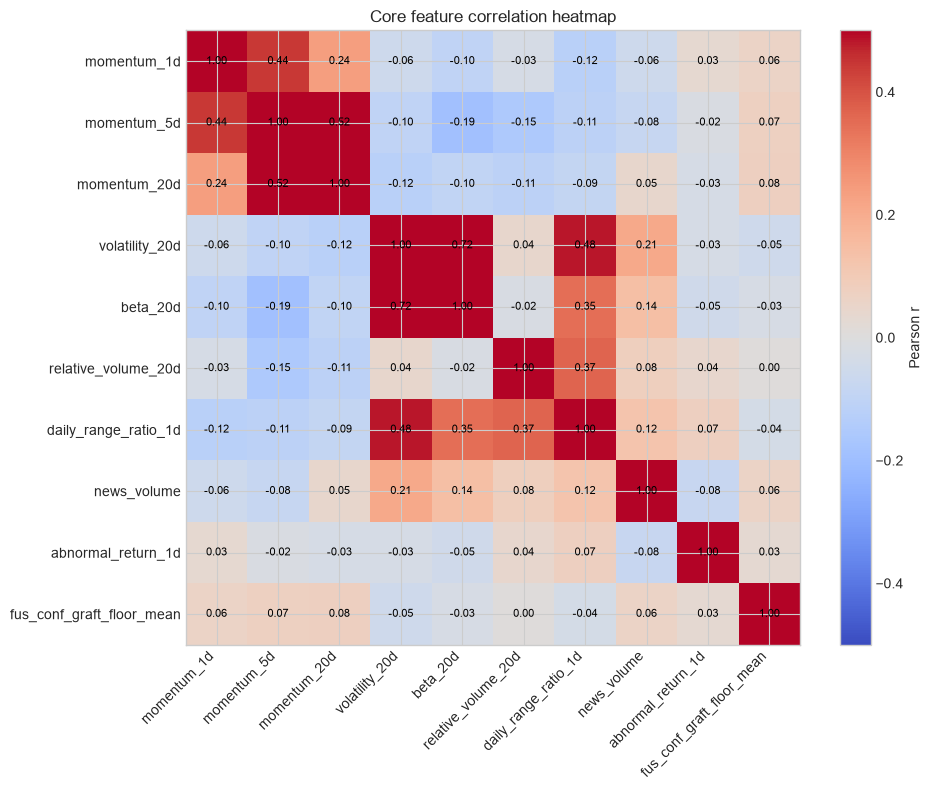


Core correlation matrix:
                            momentum_1d  momentum_5d  momentum_20d  volatility_20d  beta_20d  relative_volume_20d  daily_range_ratio_1d  news_volume  abnormal_return_1d  fus_conf_graft_floor_mean
momentum_1d                      1.000        0.445         0.236          -0.057    -0.101               -0.031                -0.120       -0.056               0.031                      0.062
momentum_5d                      0.445        1.000         0.521          -0.099    -0.188               -0.154                -0.110       -0.081              -0.016                      0.071
momentum_20d                     0.236        0.521         1.000          -0.118    -0.097               -0.113                -0.088        0.045              -0.030                      0.077
volatility_20d                  -0.057       -0.099        -0.118           1.000     0.720                0.044                 0.482        0.209              -0.030                     -0.05

In [5]:
core_cols = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d",
    "beta_20d", "relative_volume_20d", "daily_range_ratio_1d",
    "news_volume", "abnormal_return_1d", "fus_conf_graft_floor_mean",
]
core_corr = model_df[core_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(core_corr.values, cmap="coolwarm", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(core_corr.columns)))
ax.set_xticklabels(core_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(core_corr.index)))
ax.set_yticklabels(core_corr.index)
for i in range(core_corr.shape[0]):
    for j in range(core_corr.shape[1]):
        ax.text(j, i, f"{core_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
ax.set_title("Core feature correlation heatmap")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
fig.savefig(report_dir / "feature_correlation_heatmap.png", dpi=200)
plt.show()
print("\nCore correlation matrix:\n", core_corr.round(3).to_string())

### 3.3 Positive label rate

We can see for each ticker how many labels came out as positive after runnning through the final model.


Target rate by ticker:
         positive_rate  n_rows
ticker                       
TSLA           -0.071    9073
NVDA           -0.026   14113
AMZN           -0.020   11071
AAPL            0.025    7041


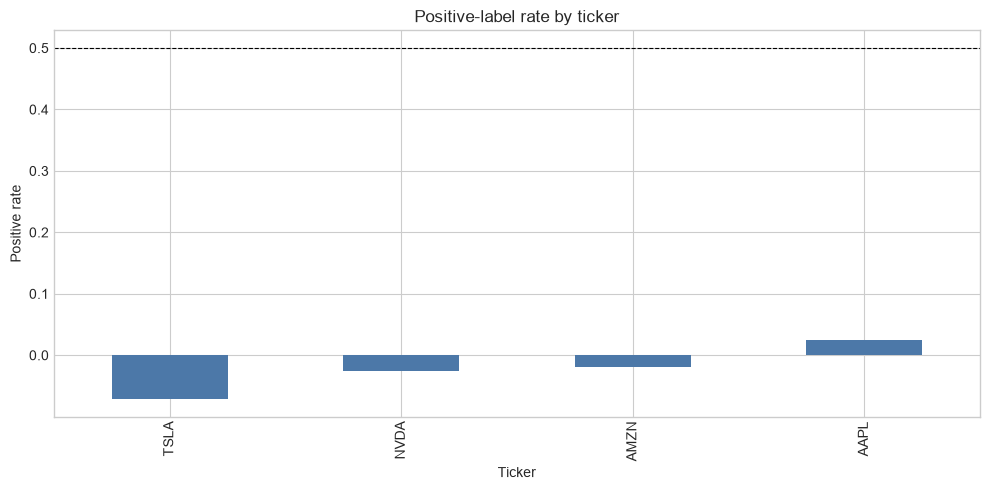

In [6]:
label_by_ticker = (
    model_df.groupby("ticker")["label_direction"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "positive_rate", "count": "n_rows"})
    .sort_values("positive_rate")
)
print("\nTarget rate by ticker:\n", label_by_ticker.round(3).head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
label_by_ticker["positive_rate"].plot(kind="bar", ax=ax, color="#4c78a8")
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Positive-label rate by ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Positive rate")
plt.tight_layout()
fig.savefig(report_dir / "label_rate_by_ticker.png", dpi=200)
plt.show()

### 3.4 Market feature correlations

Let's also plot the abnormal return against some of the most prominent market features to see how they correlate.

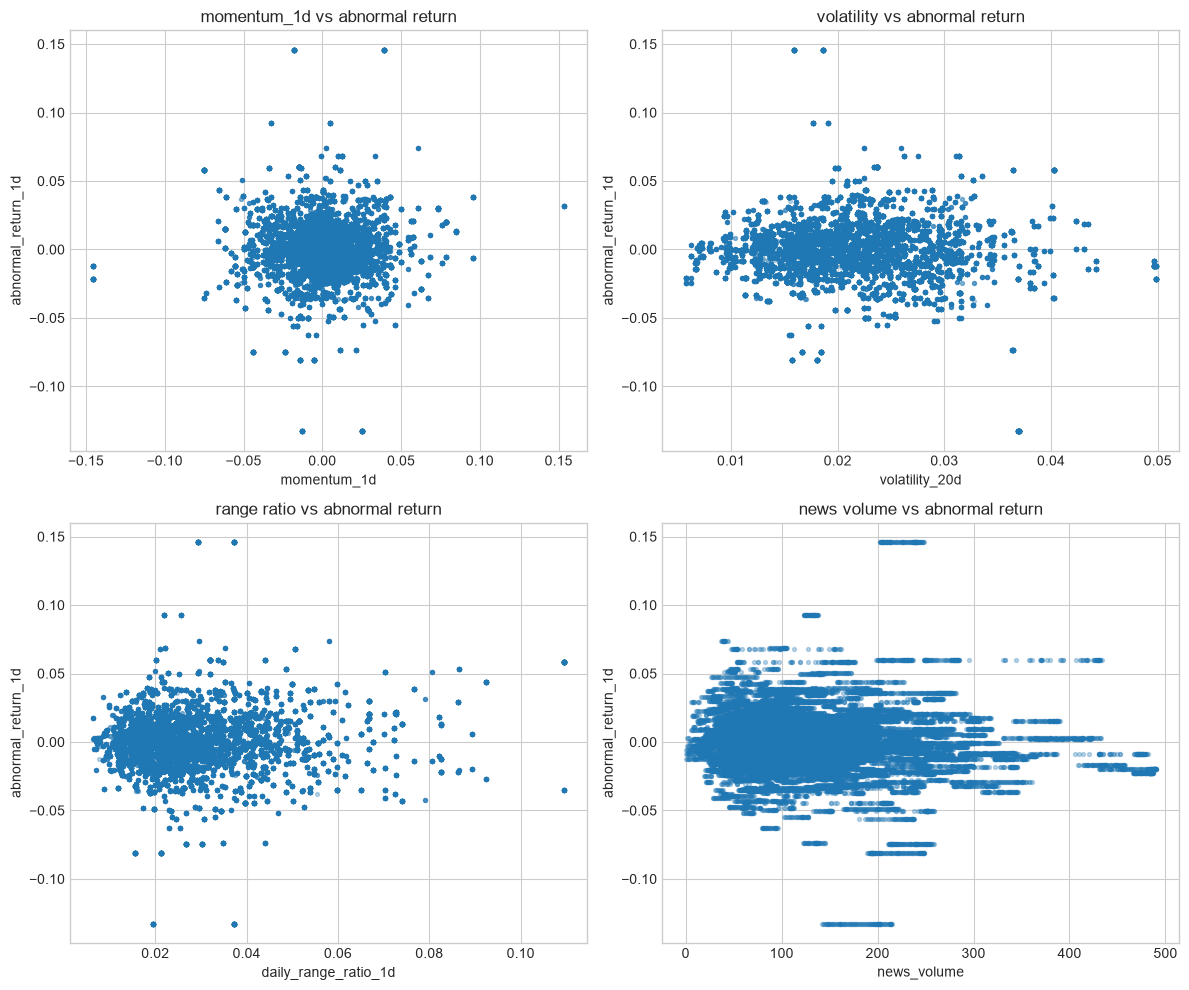

In [7]:
scatter_df = model_df[["momentum_1d", "abnormal_return_1d", "volatility_20d", "daily_range_ratio_1d", "news_volume"]].dropna()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flat

axes[0].scatter(scatter_df["momentum_1d"], scatter_df["abnormal_return_1d"], alpha=0.3, s=8)
axes[0].set_xlabel("momentum_1d")
axes[0].set_ylabel("abnormal_return_1d")
axes[0].set_title("momentum_1d vs abnormal return")

axes[1].scatter(scatter_df["volatility_20d"], scatter_df["abnormal_return_1d"], alpha=0.3, s=8)
axes[1].set_xlabel("volatility_20d")
axes[1].set_ylabel("abnormal_return_1d")
axes[1].set_title("volatility vs abnormal return")

axes[2].scatter(scatter_df["daily_range_ratio_1d"], scatter_df["abnormal_return_1d"], alpha=0.3, s=8)
axes[2].set_xlabel("daily_range_ratio_1d")
axes[2].set_ylabel("abnormal_return_1d")
axes[2].set_title("range ratio vs abnormal return")

axes[3].scatter(scatter_df["news_volume"], scatter_df["abnormal_return_1d"], alpha=0.3, s=8)
axes[3].set_xlabel("news_volume")
axes[3].set_ylabel("abnormal_return_1d")
axes[3].set_title("news volume vs abnormal return")
plt.tight_layout()
fig.savefig(report_dir / "market_signal_relationships.png", dpi=200)
plt.show()



In [ ]:
print("\nFinal model spec:\n", json.dumps({
    "model_class": "lightgbm.LGBMClassifier",
    "objective": "binary",
    "num_leaves": 31,
    "learning_rate": 0.08,
    "min_child_samples": 8,
    "n_estimators": 100,
    "subsample": 1.0,
    "subsample_freq": 3,
    "colsample_bytree": 0.5,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "max_depth": -1,
    "is_unbalance": False,
    "boosting_type": "dart",
    "random_state": 42,
    "verbosity": -1,
}, indent=2))



Saved short report to c:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\reports\findings\final-project-findings.md

Final model spec:
 {
  "model_class": "lightgbm.LGBMClassifier",
  "objective": "binary",
  "num_leaves": 31,
  "learning_rate": 0.08,
  "min_child_samples": 8,
  "n_estimators": 100,
  "subsample": 1.0,
  "subsample_freq": 3,
  "colsample_bytree": 0.5,
  "reg_alpha": 1.0,
  "reg_lambda": 5.0,
  "max_depth": -1,
  "is_unbalance": false,
  "boosting_type": "dart",
  "random_state": 42,
  "verbosity": -1
}


## 4. Final interpretation

The final judgement is unambiguous:

- the project is a successful research pipeline
- the final model is the tuned session-level LightGBM classifier
- the process took us from text feature engineering through session aggregation and tuning
- the reactivity feature family remains unproven because the current filter is too weak to support a decisive answer.

This is the correct record of the project as it stands.